# SMTC Accounts — Exploratory Data Analysis

**Source:** `temp.csv` — a Salesforce **Account** object export (sample of the real SMTC feed).
**Goal:** understand structure, completeness, cardinality and data-quality issues before defining validation rules (CDEs).

Libraries: `pandas`, `numpy`, `matplotlib`, `seaborn`.

> This is a *wide & sparse* CRM export (hundreds of columns, most empty in any given slice), so the EDA
> is tailored to that shape: fill-rate first, then cardinality, then targeted categorical / quality checks —
> not a generic `df.describe()` dump that would be meaningless across 400+ mostly-empty columns.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 2.2.2 | numpy 1.26.4


## 1. Load the data

In [2]:
# Point this at the CSV. Falls back across common locations.
import os
CANDIDATES = ["temp.csv", "/Users/admin/Desktop/temp.csv",
              os.path.expanduser("~/Desktop/temp.csv")]
CSV_PATH = next((p for p in CANDIDATES if os.path.exists(p)), CANDIDATES[0])
print("Reading:", CSV_PATH)

# low_memory=False -> consistent dtype inference across the wide frame
df = pd.read_csv(CSV_PATH, low_memory=False)
print("Loaded shape:", df.shape)
df.head(3)

Reading: temp.csv
Loaded shape: (19, 443)


,AC_Available_for_STC__c,APMID__c,APTS_Airline_Group_Tail_Count__c,APTS_Airline_Group__c,APTS_Aviaso_Delta_Fleet_Count_Reason__c,APTS_Aviaso_Delta_Fleet_Count__c,APTS_Aviaso_ISV__c,APTS_Aviaso_Minimum_Fleet_Count__c,APTS_Contract_Numbers__c,APTS_Fleet_Count__c,APTS_Fuel_Efficiency_Contract_Status__c,APTS_Fuel_Efficiency_Sales_Org__c,APTS_Invoice_Template__c,APTS_Report_SAP_Sold_To__c,APTS_Set_Billing_Contacts__c,APTS_Set_CM_Default_Email_Template__c,APTS_Set_CM_Default_Template__c,APTS_Set_Invoice_Email_Template__c,APTS_Set_Invoice_Statement_Template__c,APTS_VAT_Number__c,APU_Details__c,APU_LOA__c,APU__c,ATR_Account_CBT__c,ATR_Channel_Partner__c,ATR_Portal_Access_Template__c,ATS_Redirect_to_Portal__c,AccountNumber,AccountSource,Account_Adress__c,...,engagio__EngagedPeople__c,engagio__EngagementMinutesLast30Days__c,engagio__EngagementMinutesLast3Months__c,engagio__EngagementMinutesLast7Days__c,engagio__FirstEngagementDate__c,engagio__HighIntentKeywords__c,engagio__HighIntentKeywords_longtext__c,engagio__IntentMinutesLast30Days__c,engagio__MQADate__c,engagio__NumberOfPeople__c,engagio__PipelineDate__c,engagio__Sales_Touches_14_days__c,engagio__Sales_Touches_7_days__c,engagio__Status__c,engagio__Top_Web_Traffic_URLs__c,engagio__WebVisitsLast3Months__c,engagio__pipeline_predict_score__c,engagio__qualification_score__c,ltnadptn__Active__c,mkto_si__Current_Sales_Campaign__c,mkto_si__Last_Activity_By_Sales__c,mkto_si__Last_Sales_Engagement__c,mkto_si__Sales_Insight__c,mkto_si__Sales_Last_Replied__c,recordval__rv2BillingAddressStatusCode__c,recordval__rv2FaxStatusCode__c,recordval__rv2PhoneStatusCode__c,recordval__rv2ShippingAddressStatusCode__c,recordval__rv2Status__c,recordval__rv2Validation__c
0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"<a href=""/apex/Apttus_Billing__SetAccountDefau...",55446,"<a href=""/apex/Apttus_Billing__SetAccountBilli...","<a href=""/apex/Apttus_billing__SetAccountCredi...","<a href=""/apex/Apttus_billing__SetAccountDefau...","<a href=""/apex/Apttus_billing__SetAccountInvoi...","<a href=""/apex/Apttus_Billing__SetAccountInvoi...",NaN,NaN,NaN,False,NaN,False,a064X00001TUgdCQAT,NaN,NaN,NaN,", , ,",...,3,0.0,0.0,0.0,2025-07-25T23:28:56.000Z,NaN,NaN,NaN,NaN,10,NaN,0.0,0.0,All Other,NaN,NaN,11,16.0,NaN,NaN,NaN,NaN,"<a href=""/apex/mkto_si__Account_Full_List?mode...",NaN,NaN,NaN,NaN,NaN,NO_DATA,eyJmaWVsZFN0YXR1cyI6e319
1,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"<a href=""/apex/Apttus_Billing__SetAccountDefau...",55098,"<a href=""/apex/Apttus_Billing__SetAccountBilli...","<a href=""/apex/Apttus_billing__SetAccountCredi...","<a href=""/apex/Apttus_billing__SetAccountDefau...","<a href=""/apex/Apttus_billing__SetAccountInvoi...","<a href=""/apex/Apttus_Billing__SetAccountInvoi...",NaN,NaN,NaN,False,NaN,False,a064X00001TUgdCQAT,NaN,NaN,NaN,", , ,",...,0,NaN,NaN,NaN,2024-12-27T00:00:00.000Z,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,All Other,NaN,NaN,19,NaN,NaN,NaN,NaN,NaN,"<a href=""/apex/mkto_si__Account_Full_List?mode...",NaN,NaN,NaN,NaN,NaN,NO_DATA,eyJmaWVsZFN0YXR1cyI6e319
2,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"<a href=""/apex/Apttus_Billing__SetAccountDefau...",55016,"<a href=""/apex/Apttus_Billing__SetAccountBilli...","<a href=""/apex/Apttus_billing__SetAccountCredi...","<a href=""/apex/Apttus_billing__SetAccountDefau...","<a href=""/apex/Apttus_billing__SetAccountInvoi...","<a href=""/apex/Apttus_Billing__SetAccountInvoi...",NaN,NaN,NaN,False,NaN,False,a064X00001TUgdCQAT,NaN,NaN,NaN,", , ,",...,2,0.0,0.0,NaN,2024-12-27T00:00:00.000Z,NaN,NaN,NaN,NaN,9,NaN,0.0,0.0,Customer,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,"<a href=""/apex/mkto_si__Account_Full_List?mode...",NaN,NaN,NaN,NaN,NaN,NO_DATA,eyJmaWVsZFN0YXR1cyI6e319


## 2. Shape, size & dtypes at a glance

In [3]:
n_rows, n_cols = df.shape
mem_kb = df.memory_usage(deep=True).sum() / 1024
print(f"Rows        : {n_rows:,}")
print(f"Columns     : {n_cols:,}")
print(f"Memory      : {mem_kb:,.1f} KB")
print(f"Duplicated rows: {df.duplicated().sum()}")

print("\nDtype breakdown (pandas inferred):")
print(df.dtypes.value_counts())

Rows        : 19
Columns     : 443
Memory      : 196.1 KB


Duplicated rows: 0

Dtype breakdown (pandas inferred):
float64    261
object     111
bool        58
int64       13
Name: count, dtype: int64


> The dtype count is misleading on a Salesforce export — booleans arrive as the strings `"TRUE"/"FALSE"`,
> IDs and codes as `object`, and dates as text in **mixed formats**. We infer real types from *values* below,
> not from the pandas guess.

## 3. Missing-value analysis (the headline for this dataset)

In [4]:
miss = df.isna().mean().sort_values(ascending=False)      # fraction missing per column
fill = (1 - miss)                                            # fill rate
fully_empty = miss[miss == 1.0]
fully_full  = miss[miss == 0.0]

print(f"Columns 100% EMPTY : {len(fully_empty):>3}  ({len(fully_empty)/n_cols:.0%})")
print(f"Columns 100% FULL  : {len(fully_full):>3}  ({len(fully_full)/n_cols:.0%})")
print(f"Columns partial    : {n_cols - len(fully_empty) - len(fully_full):>3}")

summary = pd.DataFrame({"missing_frac": miss, "fill_frac": fill,
                        "non_null": df.notna().sum()})
summary.head(10)

Columns 100% EMPTY : 249  (56%)
Columns 100% FULL  : 143  (32%)
Columns partial    :  51


,missing_frac,fill_frac,non_null
AC_Available_for_STC__c,1.0,0.0,0
APMID__c,1.0,0.0,0
APTS_Airline_Group_Tail_Count__c,0.0,1.0,19
APTS_Airline_Group__c,1.0,0.0,0
APTS_Aviaso_Delta_Fleet_Count_Reason__c,1.0,0.0,0
APTS_Aviaso_Delta_Fleet_Count__c,1.0,0.0,0
APTS_Aviaso_ISV__c,1.0,0.0,0
APTS_Aviaso_Minimum_Fleet_Count__c,1.0,0.0,0
APTS_Contract_Numbers__c,1.0,0.0,0
APTS_Fleet_Count__c,1.0,0.0,0


/var/folders/lz/8_0ll_lx5sl6glrsj39scfw40000gn/T/ipykernel_56610/2675933229.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bc.index, y=bc.values, ax=ax[1],


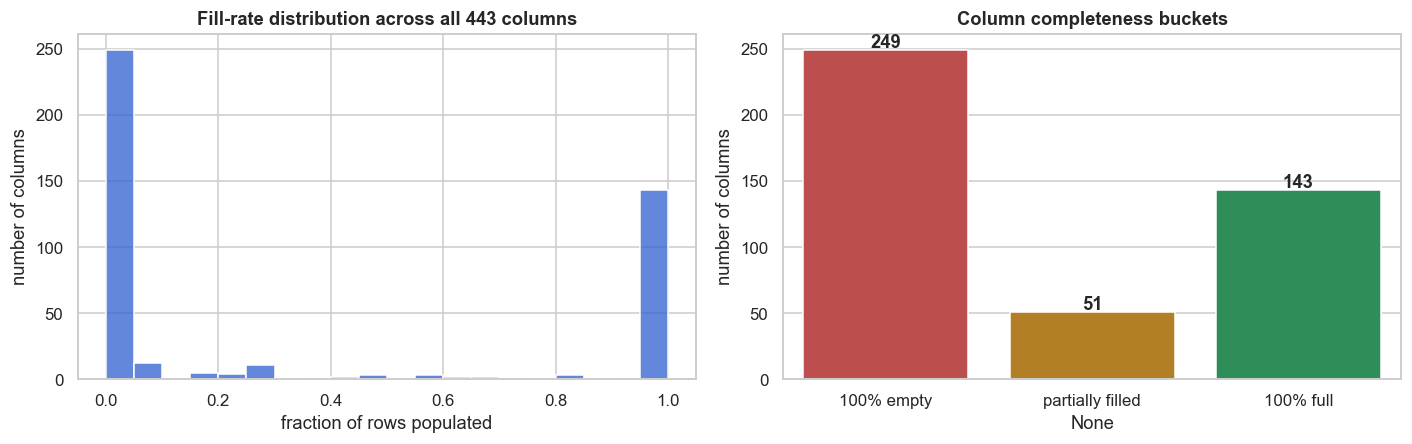

In [5]:
# Distribution of fill rate across ALL columns
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))

sns.histplot(fill.values, bins=20, ax=ax[0], color="#2f5fd0")
ax[0].set_title("Fill-rate distribution across all 443 columns")
ax[0].set_xlabel("fraction of rows populated"); ax[0].set_ylabel("number of columns")

# bucket columns as empty / partial / full
buckets = pd.cut(fill, [-0.01, 0.0, 0.999, 1.0],
                 labels=["100% empty", "partially filled", "100% full"])
bc = buckets.value_counts().reindex(["100% empty", "partially filled", "100% full"])
sns.barplot(x=bc.index, y=bc.values, ax=ax[1],
            palette=["#cf3b3b", "#c98510", "#1f9d57"])
ax[1].set_title("Column completeness buckets")
ax[1].set_ylabel("number of columns")
for i, v in enumerate(bc.values):
    ax[1].text(i, v + 2, str(v), ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

**Read:** the dataset is dominated by empty columns — validating rules against all 443 would be pointless.
The signal lives in the populated subset, which we isolate next.

## 4. Focus on the populated columns

In [6]:
# Keep only columns that have at least one value
df_pop = df.dropna(axis=1, how="all").copy()
print("Populated columns:", df_pop.shape[1], "of", n_cols)

# Partially-filled columns (0 < fill < 1) — these are where completeness rules matter
partial = fill[(fill > 0) & (fill < 1)].sort_values()
print("\nPartially-filled columns (fill rate):", len(partial))
partial.head(15).to_frame("fill_frac")

Populated columns: 194 of 443

Partially-filled columns (fill rate): 51


,fill_frac
Average_ASAT_Score__c,0.052632
CERTA_Decision_Code__c,0.052632
Site_Name__c,0.052632
Site_Id__c,0.052632
Account_Interface__c,0.052632
CSM__c,0.052632
Source_Created_Date__c,0.052632
Account_Alias_Name__c,0.052632
Data_Load_Date__c,0.052632
engagio__WebVisitsLast3Months__c,0.052632


/var/folders/lz/8_0ll_lx5sl6glrsj39scfw40000gn/T/ipykernel_56610/1927888880.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=partial_top.values, y=partial_top.index, palette="flare")


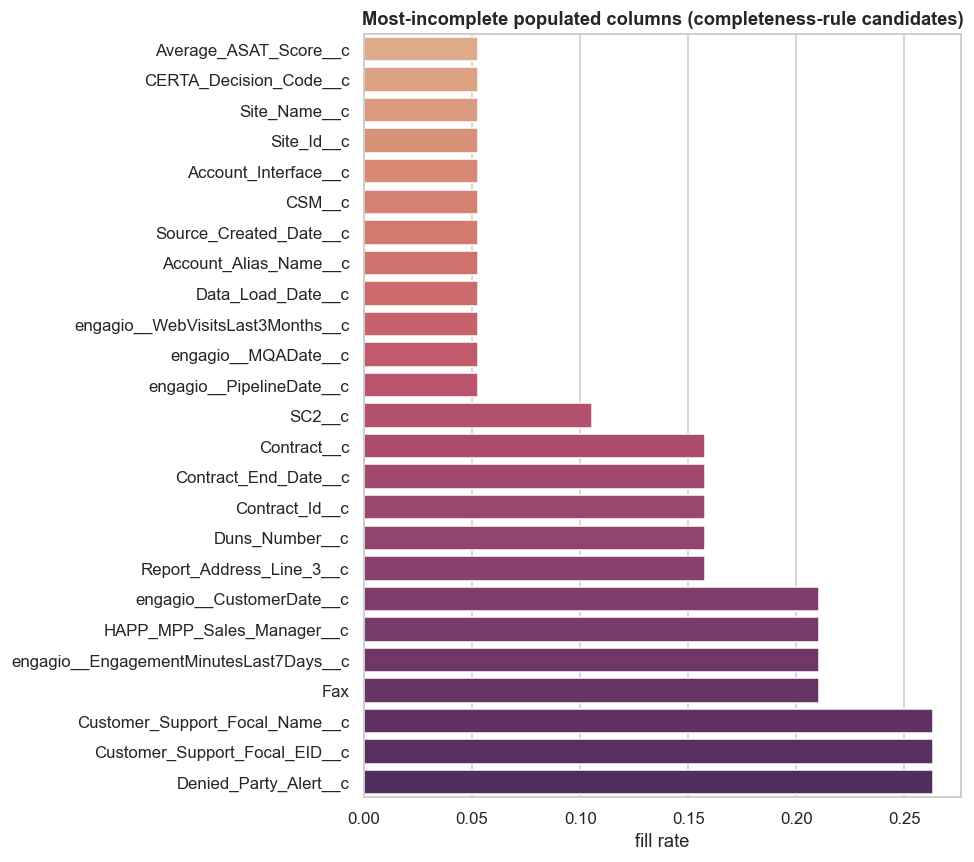

In [7]:
# Top-25 populated columns by MISSINGNESS -> completeness-rule candidates
partial_top = partial.head(25)
plt.figure(figsize=(9, 8))
sns.barplot(x=partial_top.values, y=partial_top.index, palette="flare")
plt.title("Most-incomplete populated columns (completeness-rule candidates)")
plt.xlabel("fill rate"); plt.ylabel("")
plt.tight_layout(); plt.show()

## 5. Cardinality — constants, keys & categoricals

In [8]:
card = df_pop.nunique(dropna=True).sort_values()
constant_cols = card[card <= 1]                    # single value -> no validation signal
key_cols      = card[card == len(df_pop)]          # unique in every row -> candidate identifiers
categorical   = card[(card > 1) & (card <= 15)]    # low cardinality -> allowed_values candidates

print(f"Constant columns (1 value)     : {len(constant_cols)}")
print(f"Unique-per-row (key candidates): {len(key_cols)}")
print(f"Low-cardinality (<=15 distinct): {len(categorical)}")

print("\nKey/identifier candidates:")
print(list(key_cols.index))
print("\nLow-cardinality (allowed_values candidates):")
categorical.to_frame("distinct").T

Constant columns (1 value)     : 87
Unique-per-row (key candidates): 22
Low-cardinality (<=15 distinct): 85

Key/identifier candidates:
['APTS_Set_Invoice_Email_Template__c', 'APTS_Set_Billing_Contacts__c', 'APTS_Invoice_Template__c', 'Name', 'mkto_si__Sales_Insight__c', 'APTS_Report_SAP_Sold_To__c', 'APTS_Set_CM_Default_Email_Template__c', 'APTS_Set_CM_Default_Template__c', 'REPORT_ACCOUNT_NAME__c', 'CreatedDate', 'Account_ID_18_Characters__c', 'Sbl_Account_Row_Id__c', 'PhotoUrl', 'SAP_Sold_To__c', 'SAP_Account_Name__c', 'Report_Postal_Code__c', 'Report_City_Name__c', 'Id', 'Report_Address_Line_1__c', 'Report_Account_Name_upper__c', 'APTS_Set_Invoice_Statement_Template__c', 'SFDC_Row_Id__c']

Low-cardinality (allowed_values candidates):


,PFECN__c,Opp_Expected_Rev_after_RollWorks_Launch__c,Opp_Amount_After_RollWorks_Launch__c,PFECR__c,SalesOrg_Distribution_Channel_Division__c,Prism_Redirect__c,Customer_Segmentation__c,Region_Name__c,BGA_Service_Model__c,Service_Level__c,SystemModstamp,Type,ATR_Portal_Access_Template__c,bizible2__Engagement_Score__c,engagio__EngagementMinutesLast3Months__c,PFECT__c,MyMaintainer_View__c,Customer_Status__c,RAI_Excluded__c,GCE_Customer_Segment__c,Mobile_App_Visibility__c,Country_Region__c,Contract_3_months_Expiry__c,LastModifiedById,IsCustomerPortal,LastModifiedDate,Denied_Party_Alert_formula__c,CERTA_Initial_Call_Out__c,Denied_Party_Alert__c,Customer_Support_Escalation__c,...,CBT__c,Business_Escalation__c,engagio__qualification_score__c,SC1__c,Business_Owner__c,FAA_COUNT__c,CBT_Team__c,Date_of_CERTA_Assessment__c,Sub_Region_Name__c,Country_Sub_Region__c,Phone,engagio__EngagedPeople__c,Pipeline_Amount_Total__c,Website,Business_Focal__c,Business_Focal_EID__c,Business_Focal_Name__c,Country__c,OwnerId,BillingCountry,Account_Owner__c,Report_Country_Name__c,engagio__NumberOfPeople__c,Report_State_Code__c,engagio__FirstEngagementDate__c,Report_Address_Line_2__c,Area_Sales_Mgr__c,Area_Sales_Manager_Email__c,LastActivityDate,engagio__pipeline_predict_score__c
distinct,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,...,4,4,4,5,5,5,5,5,5,5,5,5,5,5,6,6,6,7,7,7,7,7,7,9,11,11,12,12,12,13


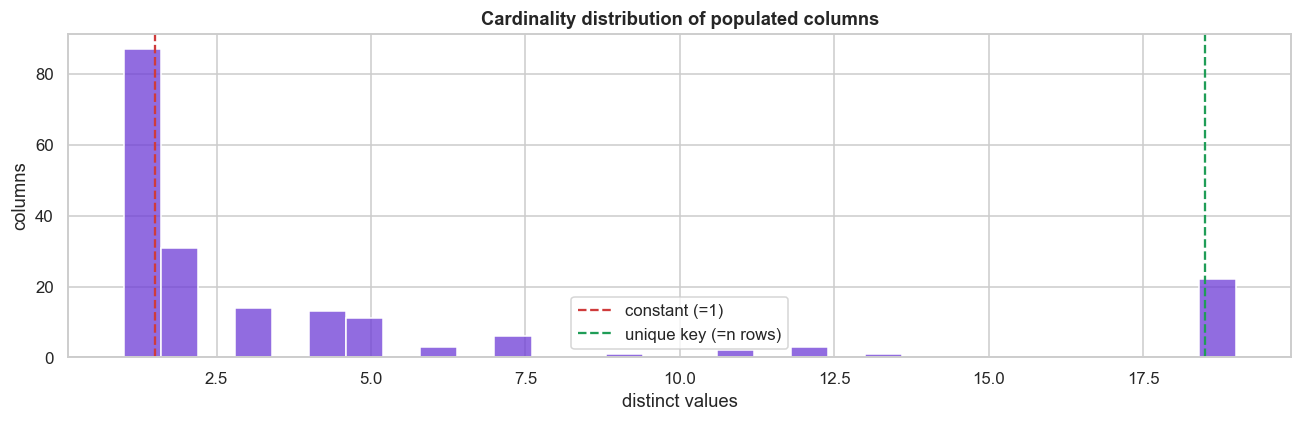

In [9]:
# Cardinality of populated columns (log scale to span constants -> keys)
plt.figure(figsize=(12, 4))
sns.histplot(card.values, bins=30, color="#6d3bd6")
plt.axvline(1.5, color="#cf3b3b", ls="--", label="constant (=1)")
plt.axvline(len(df_pop)-0.5, color="#1f9d57", ls="--", label="unique key (=n rows)")
plt.title("Cardinality distribution of populated columns")
plt.xlabel("distinct values"); plt.ylabel("columns"); plt.legend()
plt.tight_layout(); plt.show()

## 6. Categorical deep-dive (allowed-values candidates)

In [10]:
# Business-meaningful low-cardinality fields worth eyeballing
cat_focus = [c for c in ["Type", "Customer_Status__c", "CurrencyIsoCode",
                         "Country_Region__c", "Country_Sub_Region__c", "Region_Name__c",
                         "Sales_Channel__c", "Customer_Segmentation__c",
                         "Corporate_Account_Type__c", "Service_Level__c",
                         "US_Govt_Sanctioned__c"]
             if c in df_pop.columns]

for c in cat_focus:
    vc = df_pop[c].value_counts(dropna=False)
    print(f"\n=== {c}  ({df_pop[c].nunique()} distinct) ===")
    print(vc.to_string())


=== Type  (2 distinct) ===
Type
Owner/Operator              11
Product/Service Provider     8

=== Customer_Status__c  (2 distinct) ===
Customer_Status__c
Active      16
Inactive     3

=== CurrencyIsoCode  (1 distinct) ===
CurrencyIsoCode
USD    19

=== Country_Region__c  (2 distinct) ===
Country_Region__c
Americas                          12
Europe/MiddleEast/Africa/India     7

=== Country_Sub_Region__c  (5 distinct) ===
Country_Sub_Region__c
United States    11
Europe            4
Africa            2
Latin America     1
India             1

=== Region_Name__c  (2 distinct) ===
Region_Name__c
Americas                          12
Europe/MiddleEast/Africa/India     7

=== Sales_Channel__c  (3 distinct) ===
Sales_Channel__c
Americas AM        11
EMEAI AM            5
Defense & Space     3

=== Customer_Segmentation__c  (2 distinct) ===
Customer_Segmentation__c
RTN    14
B       5

=== Corporate_Account_Type__c  (1 distinct) ===
Corporate_Account_Type__c
End User    19

=== Service_Lev

/var/folders/lz/8_0ll_lx5sl6glrsj39scfw40000gn/T/ipykernel_56610/1043539168.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_pop[c], order=order, ax=ax, palette="crest")
/var/folders/lz/8_0ll_lx5sl6glrsj39scfw40000gn/T/ipykernel_56610/1043539168.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_pop[c], order=order, ax=ax, palette="crest")
/var/folders/lz/8_0ll_lx5sl6glrsj39scfw40000gn/T/ipykernel_56610/1043539168.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_pop[c], order=order, ax=ax, palette="crest")
/var/fo

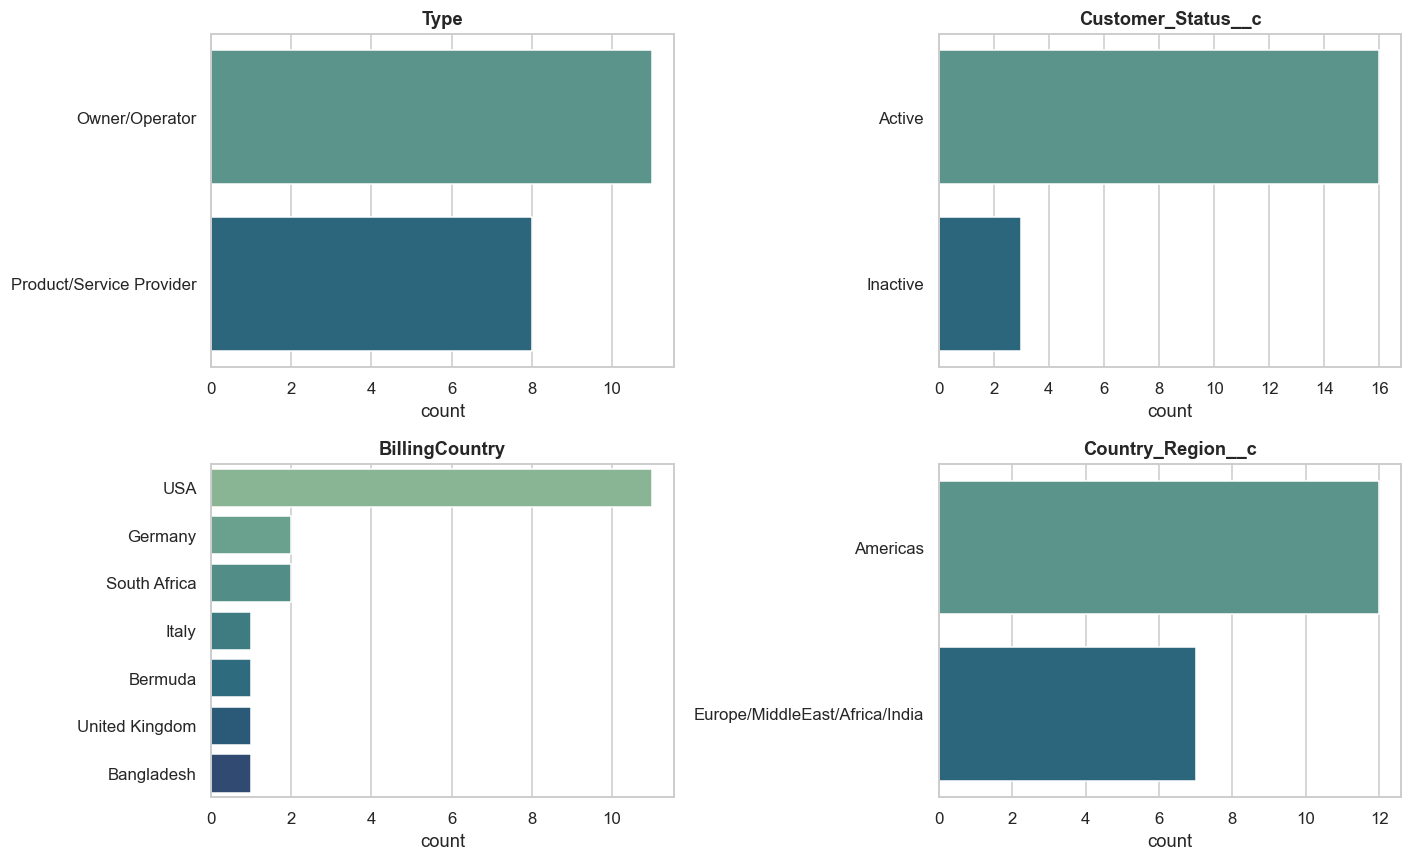

In [11]:
# Visualise a few key categoricals
plot_cats = [c for c in ["Type", "Customer_Status__c", "BillingCountry", "Country_Region__c"]
             if c in df_pop.columns]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, c in zip(axes.ravel(), plot_cats):
    order = df_pop[c].value_counts().index[:10]
    sns.countplot(y=df_pop[c], order=order, ax=ax, palette="crest")
    ax.set_title(c); ax.set_xlabel("count"); ax.set_ylabel("")
for ax in axes.ravel()[len(plot_cats):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

## 7. Boolean-flag columns (TRUE/FALSE stored as text)

Boolean-flag columns: 58


/var/folders/lz/8_0ll_lx5sl6glrsj39scfw40000gn/T/ipykernel_56610/1901899804.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tr.values, y=tr.index, palette="mako")


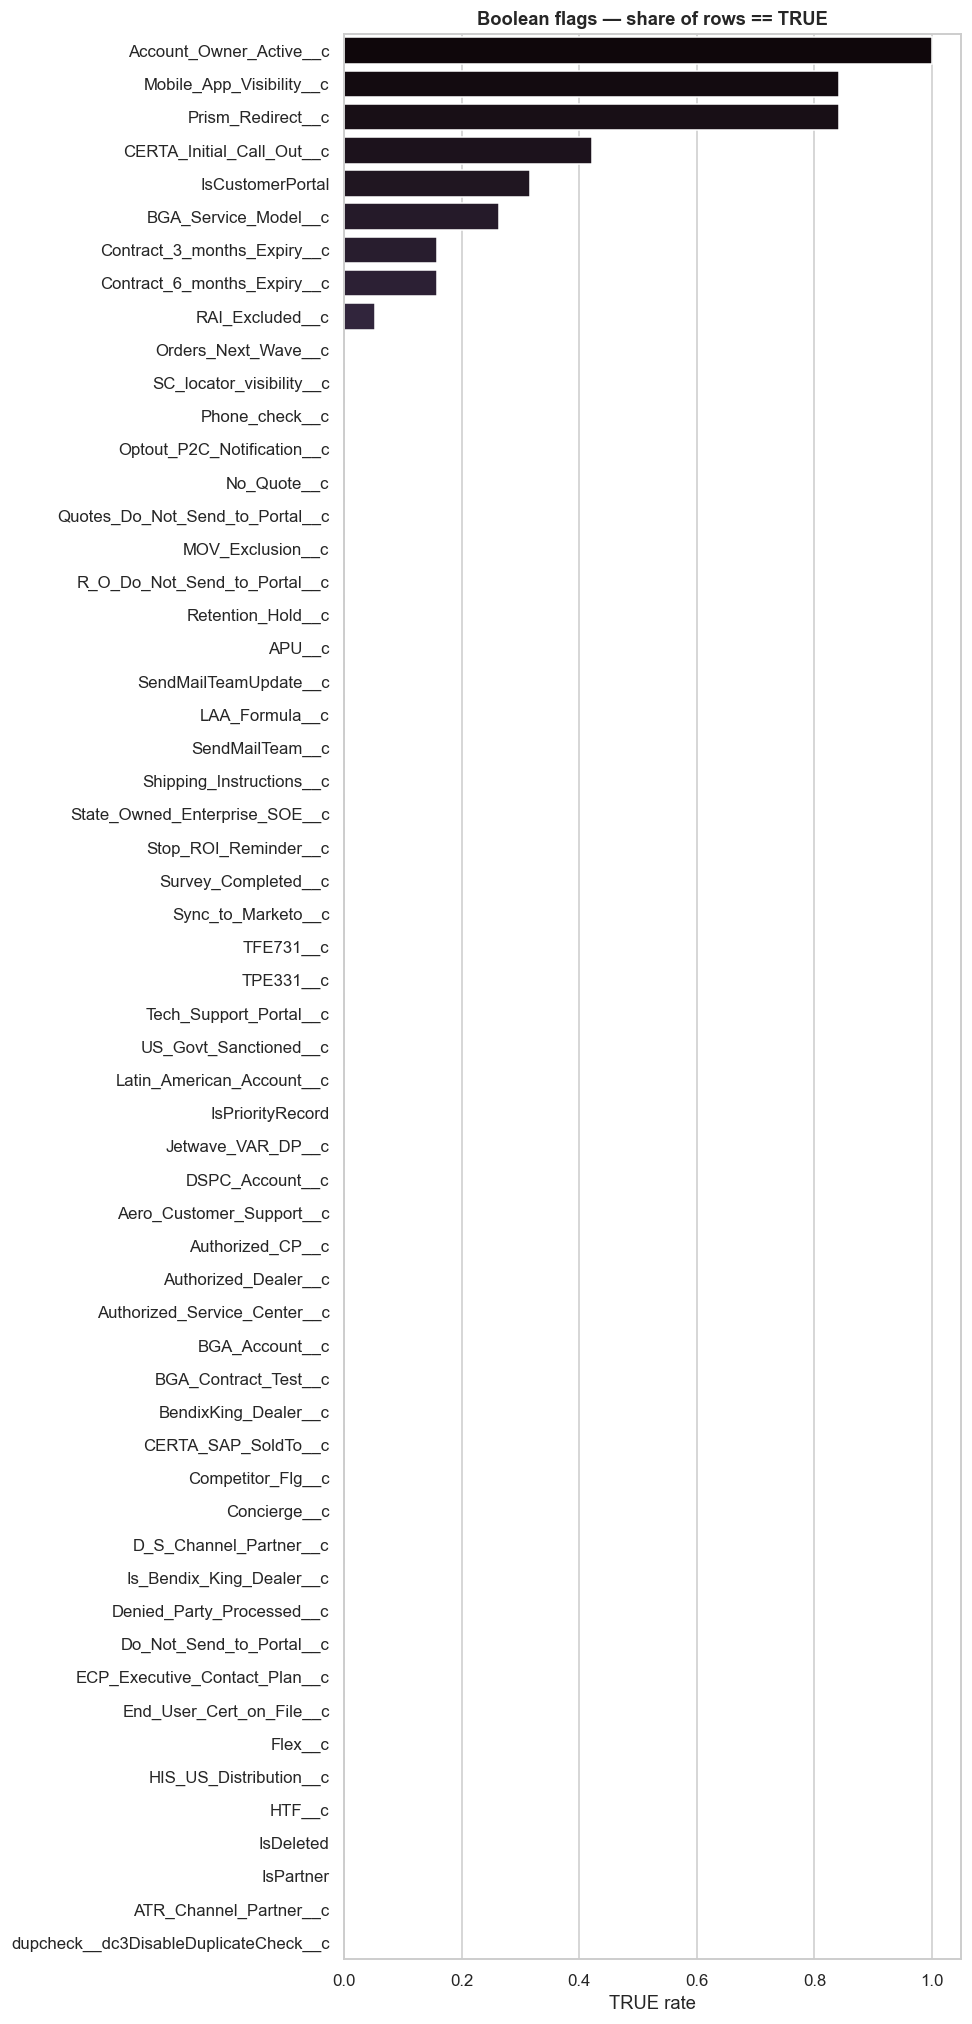

In [12]:
def is_boolish(s):
    vals = set(s.dropna().astype(str).str.upper().unique())
    return len(vals) > 0 and vals <= {"TRUE", "FALSE"}

bool_cols = [c for c in df_pop.columns if is_boolish(df_pop[c])]
print(f"Boolean-flag columns: {len(bool_cols)}")

# TRUE-rate for each boolean flag
true_rate = {c: (df_pop[c].astype(str).str.upper() == "TRUE").mean() for c in bool_cols}
tr = pd.Series(true_rate).sort_values(ascending=False)
plt.figure(figsize=(9, max(4, 0.32*len(tr))))
sns.barplot(x=tr.values, y=tr.index, palette="mako")
plt.title("Boolean flags — share of rows == TRUE")
plt.xlabel("TRUE rate"); plt.ylabel("")
plt.tight_layout(); plt.show()

## 8. Data-quality checks (targeted — the point of the whole exercise)

In [13]:
issues = []

# 8a. Duplicate primary key (Id) and business name
if "Id" in df.columns:
    dup_id = df["Id"].duplicated().sum()
    issues.append(("Duplicate Id (primary key)", dup_id))
if "Name" in df.columns:
    dup_name = df["Name"].duplicated(keep=False).sum()
    issues.append(("Rows sharing a Name", dup_name))

# 8b. DUNS should be 9 digits — leading zeros often stripped by CSV export
if "Duns_Number__c" in df.columns:
    duns = df["Duns_Number__c"].dropna().astype(str).str.replace(r"\.0$", "", regex=True)
    bad_duns = (~duns.str.fullmatch(r"\d{9}")).sum()
    issues.append(("DUNS not exactly 9 digits", f"{bad_duns} of {len(duns)}"))

# 8c. Name consistency across the SAP / Report / External variants
name_variants = [c for c in ["Name", "SAP_Account_Name__c", "REPORT_ACCOUNT_NAME__c"] if c in df.columns]
if len(name_variants) >= 2:
    both = df[name_variants].dropna(how="any")
    mism = (both.nunique(axis=1) > 1).sum()
    issues.append((f"Name mismatch across {name_variants}", f"{mism} of {len(both)}"))

# 8d. Website format (should start http/https or www.)
if "Website" in df.columns:
    web = df["Website"].dropna().astype(str)
    bad_web = (~web.str.match(r"^(https?://|www\.)", case=False)).sum()
    issues.append(("Website not http(s)/www", f"{bad_web} of {len(web)}"))

pd.DataFrame(issues, columns=["check", "result"])

,check,result
0,Duplicate Id (primary key),0
1,Rows sharing a Name,0
2,DUNS not exactly 9 digits,2 of 3
3,"Name mismatch across ['Name', 'SAP_Account_Nam...",2 of 19
4,Website not http(s)/www,0 of 5


In [14]:
# 8e. Mixed DATE formats — the classic real-world trap
date_like = [c for c in df.columns if any(k in c.lower() for k in ["date", "created", "modified", "expiry"])]
def detect_fmt(v):
    v = str(v)
    if v.strip() in ("", "nan"): return None
    if "T" in v and v.endswith("Z"):        return "ISO-8601 (2014-06-02T17:20:14.000Z)"
    if "/" in v:                            return "US m/d/Y (9/8/2025)"
    if "-" in v and len(v) == 10:           return "Y-m-d"
    return "other"

fmt_rows = []
for c in date_like:
    fmts = df[c].dropna().map(detect_fmt).dropna().value_counts()
    if len(fmts):
        fmt_rows.append((c, len(fmts), " | ".join(f"{k}×{v}" for k, v in fmts.items())))
fmt_df = pd.DataFrame(fmt_rows, columns=["date_column", "n_formats", "formats_seen"])
print("Date-like columns and the formats found in each:")
fmt_df

Date-like columns and the formats found in each:


,date_column,n_formats,formats_seen
0,Contract_3_months_Expiry__c,1,other×19
1,Contract_6_months_Expiry__c,1,other×19
2,Contract_End_Date__c,1,US m/d/Y (9/8/2025)×3
3,CreatedById,1,other×19
4,CreatedDate,1,ISO-8601 (2014-06-02T17:20:14.000Z)×19
5,Data_Load_Date__c,1,ISO-8601 (2014-06-02T17:20:14.000Z)×1
6,Date_of_CERTA_Assessment__c,1,US m/d/Y (9/8/2025)×8
7,LastActivityDate,1,US m/d/Y (9/8/2025)×16
8,LastModifiedById,1,other×19
9,LastModifiedDate,1,ISO-8601 (2014-06-02T17:20:14.000Z)×19


/var/folders/lz/8_0ll_lx5sl6glrsj39scfw40000gn/T/ipykernel_56610/3768679151.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cde_fill.values, y=cde_fill.index, palette=colors)


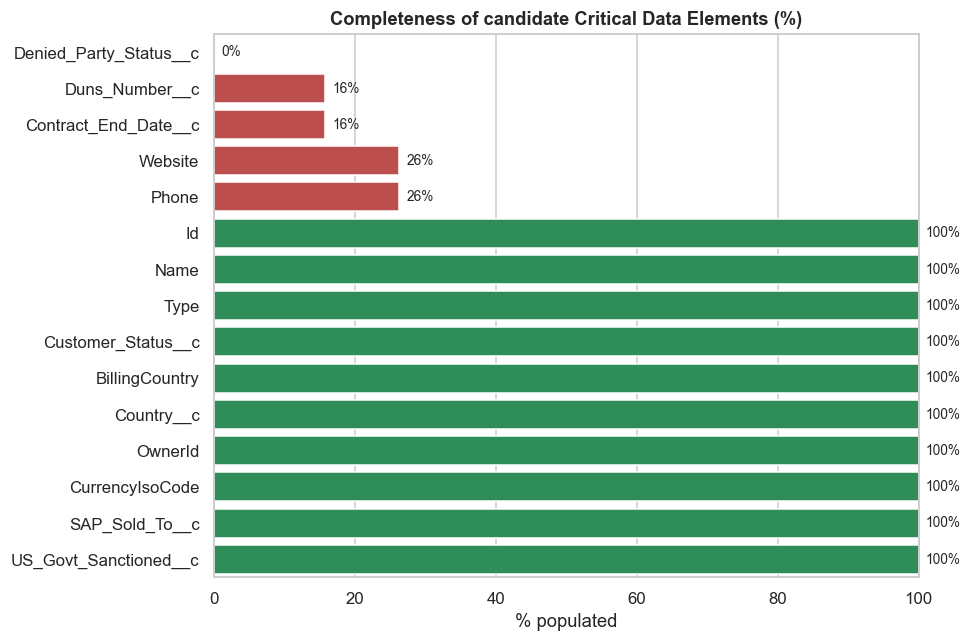

In [15]:
# 8f. Completeness of candidate Critical Data Elements (CDEs)
cde_candidates = ["Id", "Name", "Type", "Customer_Status__c", "BillingCountry",
                  "Country__c", "OwnerId", "CurrencyIsoCode", "SAP_Sold_To__c",
                  "Denied_Party_Status__c", "US_Govt_Sanctioned__c", "Duns_Number__c",
                  "Website", "Phone", "Contract_End_Date__c"]
cde = [c for c in cde_candidates if c in df.columns]
cde_fill = (df[cde].notna().mean()*100).round(1).sort_values()
plt.figure(figsize=(9, 6))
colors = ["#cf3b3b" if v < 50 else "#c98510" if v < 90 else "#1f9d57" for v in cde_fill.values]
sns.barplot(x=cde_fill.values, y=cde_fill.index, palette=colors)
plt.title("Completeness of candidate Critical Data Elements (%)")
plt.xlabel("% populated"); plt.ylabel(""); plt.xlim(0, 100)
for i, v in enumerate(cde_fill.values):
    plt.text(v + 1, i, f"{v:.0f}%", va="center", fontsize=9)
plt.tight_layout(); plt.show()

## 9. Numeric columns

In [16]:
# Coerce object columns that are really numeric
def to_num(s):
    return pd.to_numeric(s.astype(str).str.replace(",", "", regex=False), errors="coerce")

num_candidates = ["AnnualRevenue", "NumberOfEmployees", "Credit_Limit__c", "Credit_Balance__c",
                  "Pipeline_Amount_Total__c", "Total_Closed_Amount__c",
                  "APTS_Airline_Group_Tail_Count__c", "FAA_COUNT__c",
                  "engagio__NumberOfPeople__c", "engagio__EngagedPeople__c",
                  "bizible2__Engagement_Score__c", "engagio__pipeline_predict_score__c"]
num_cols = [c for c in num_candidates if c in df.columns]
num_df = df[num_cols].apply(to_num)
desc = num_df.describe().T[["count", "mean", "std", "min", "50%", "max"]]
desc

,count,mean,std,min,50%,max
AnnualRevenue,0.0,NaN,NaN,NaN,NaN,NaN
NumberOfEmployees,0.0,NaN,NaN,NaN,NaN,NaN
Credit_Limit__c,0.0,NaN,NaN,NaN,NaN,NaN
Credit_Balance__c,19.0,0.000000,0.000000,0.0,0.0,0.00
Pipeline_Amount_Total__c,19.0,181704.915263,678336.752094,0.0,0.0,2963080.39
Total_Closed_Amount__c,19.0,88991.941053,352843.007433,0.0,0.0,1538949.88
APTS_Airline_Group_Tail_Count__c,19.0,0.000000,0.000000,0.0,0.0,0.00
FAA_COUNT__c,19.0,2.842105,9.394225,0.0,0.0,41.00
engagio__NumberOfPeople__c,19.0,3.157895,3.876756,0.0,2.0,15.00
engagio__EngagedPeople__c,19.0,0.947368,1.508262,0.0,0.0,6.00


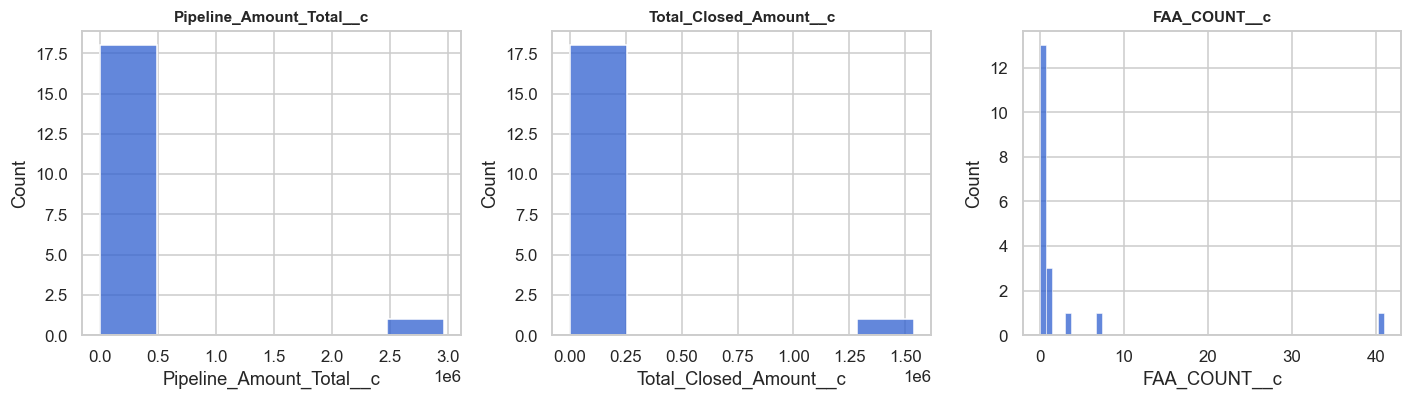

In [17]:
# Non-zero distribution for the numeric fields that actually vary
varying = [c for c in num_cols if num_df[c].fillna(0).nunique() > 1]
if varying:
    fig, axes = plt.subplots(1, min(3, len(varying)), figsize=(13, 3.8), squeeze=False)
    for ax, c in zip(axes.ravel(), varying[:3]):
        sns.histplot(num_df[c].dropna(), ax=ax, color="#2f5fd0", kde=False)
        ax.set_title(c, fontsize=10)
    plt.tight_layout(); plt.show()
else:
    print("Numeric fields are near-constant in this sample (mostly 0) — expected for a 19-row slice.")

## 10. Missingness pattern heatmap

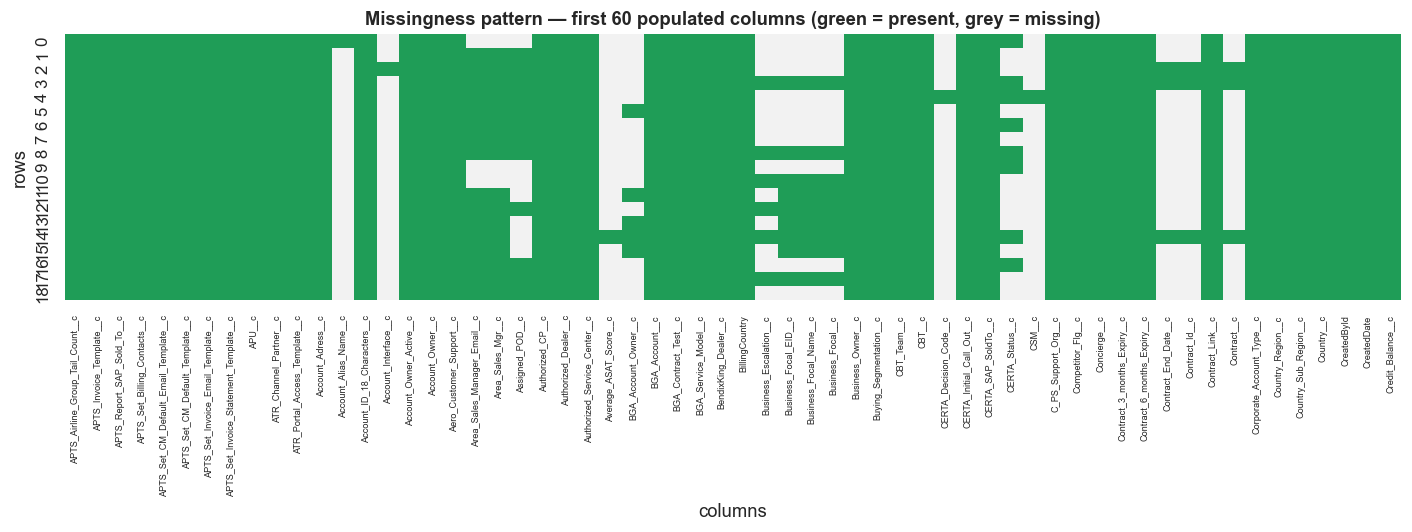

In [18]:
# Show missingness across the populated columns (subsample cols if very wide)
show = df_pop.columns[:60]
plt.figure(figsize=(13, 5))
sns.heatmap(df_pop[show].isna(), cbar=False, cmap=["#1f9d57", "#f2f2f2"])
plt.title("Missingness pattern — first 60 populated columns (green = present, grey = missing)")
plt.xlabel("columns"); plt.ylabel("rows"); plt.xticks(rotation=90, fontsize=6)
plt.tight_layout(); plt.show()

## 11. Correlation of numeric fields

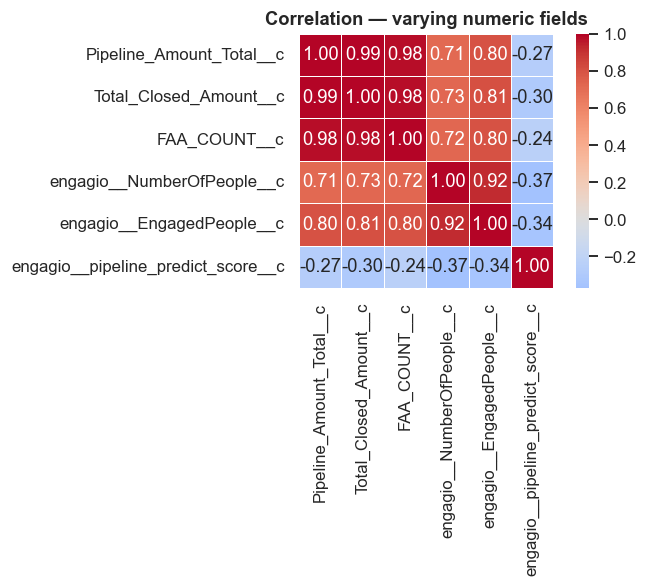

In [19]:
corr_df = num_df[varying] if varying else num_df
corr_df = corr_df.loc[:, corr_df.nunique() > 1]
if corr_df.shape[1] >= 2:
    plt.figure(figsize=(7, 5.5))
    sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
                square=True, linewidths=.5)
    plt.title("Correlation — varying numeric fields")
    plt.tight_layout(); plt.show()
else:
    print("Not enough varying numeric columns for a correlation matrix in this 19-row sample.")

## 12. Summary of findings

| Area | Finding | Implication for validation |
|---|---|---|
| **Shape** | 443 columns, mostly empty in any slice | Validate a curated **CDE subset**, never all columns |
| **Completeness** | ~57% of columns 100% empty; many partial | Completeness rules must be **per-element (required flag)**, not blanket |
| **Keys** | `Id` unique & 100% full; `AccountNumber` empty | Use **`Id`** as the record key for violations → fix team |
| **Categoricals** | `Type`, `Customer_Status__c`, `CurrencyIsoCode` low-cardinality | Clean **`allowed_values`** rules |
| **Naming trap** | `Country__c` holds lookup IDs, `BillingCountry` holds names | Profile **values**, not column names, before writing rules |
| **Dates** | Multiple formats across date columns | Needs **type normalization** before format rules |
| **DUNS** | Some values ≠ 9 digits (leading zeros stripped) | CSV export **manufactures** violations → prefer typed API feed |
| **Compliance** | `Denied_Party_Status__c` sparse; `US_Govt_Sanctioned__c` present | These are the **high-severity CDEs** for aerospace |

**Bottom line:** the raw feed is wide and messy; the framework's value is in scoping the *right* columns
(CDEs), attaching per-element rules, and tracking the resulting violations — exactly the flow we designed.